In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\ganes\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
dx=pd.read_csv('titanic_train.csv')
dx

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df=pd.DataFrame(dx)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<AxesSubplot:>

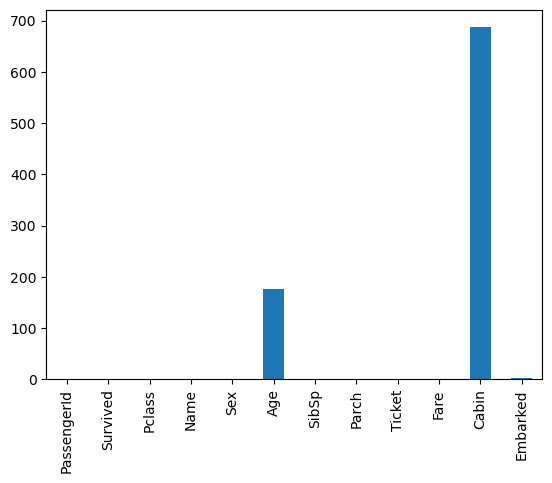

In [6]:
df.isnull().sum().plot(kind='bar')

# Observation:
    Titanic Dataset has 891 rows and 12 columns present it.
    This dataset has 177 and 687 null values present in the dataset of features 'Age' and 'Cabin'.
    It has 5 categorical value and 7 Numerical value present in it.

# Recover missing value in feature AGE

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.Age.unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [9]:
def extract_title(name):
    import re
    title_search=re.search('([A-Za-z]+)\.',name)
    if title_search:
        return title_search.group(1)
    return ""
df['Title']=df['Name'].apply(extract_title)

In [10]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr


In [11]:
df.Title.unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [12]:
df.Title.value_counts()

Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: Title, dtype: int64

In [13]:
df[df.Title=='Miss'].isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             36
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          135
Embarked         1
Title            0
dtype: int64

In [14]:
title_median_age= df.groupby('Title')['Age'].median()
print(title_median_age)

Title
Capt        70.0
Col         58.0
Countess    33.0
Don         40.0
Dr          46.5
Jonkheer    38.0
Lady        48.0
Major       48.5
Master       3.5
Miss        21.0
Mlle        24.0
Mme         24.0
Mr          30.0
Mrs         35.0
Ms          28.0
Rev         46.5
Sir         49.0
Name: Age, dtype: float64


In [15]:
df['Age'].fillna(df['Title'].map(title_median_age),inplace=True)

In [16]:
df.Age=df.Age.astype('int64')

In [17]:
df[df.Title=='Master']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.0750,NaN,S,Master
16,17,0,3,"Rice, Master. Eugene",male,2,4,1,382652,29.1250,NaN,Q,Master
50,51,0,3,"Panula, Master. Juha Niilo",male,7,4,1,3101295,39.6875,NaN,S,Master
59,60,0,3,"Goodwin, Master. William Frederick",male,11,5,2,CA 2144,46.9000,NaN,S,Master
63,64,0,3,"Skoog, Master. Harald",male,4,3,2,347088,27.9000,NaN,S,Master
65,66,1,3,"Moubarek, Master. Gerios",male,3,1,1,2661,15.2458,NaN,C,Master
78,79,1,2,"Caldwell, Master. Alden Gates",male,0,0,2,248738,29.0000,NaN,S,Master
125,126,1,3,"Nicola-Yarred, Master. Elias",male,12,1,0,2651,11.2417,NaN,C,Master
159,160,0,3,"Sage, Master. Thomas Henry",male,3,8,2,CA. 2343,69.5500,NaN,S,Master
164,165,0,3,"Panula, Master. Eino Viljami",male,1,4,1,3101295,39.6875,NaN,S,Master


In [18]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
dtype: int64

In [19]:
df['Cabin_Present']=df['Cabin'].notna().astype(int) #created new column in which cabin is present or not

In [20]:
df['Cabin_Present'].value_counts()

0    687
1    204
Name: Cabin_Present, dtype: int64

In [21]:
df.isnull().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin            687
Embarked           2
Title              0
Cabin_Present      0
dtype: int64

In [22]:
mode_embarked=df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked,inplace=True)

In [23]:
df.isnull().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin            687
Embarked           0
Title              0
Cabin_Present      0
dtype: int64

# EDA

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    891 non-null    int64  
 1   Survived       891 non-null    int64  
 2   Pclass         891 non-null    int64  
 3   Name           891 non-null    object 
 4   Sex            891 non-null    object 
 5   Age            891 non-null    int64  
 6   SibSp          891 non-null    int64  
 7   Parch          891 non-null    int64  
 8   Ticket         891 non-null    object 
 9   Fare           891 non-null    float64
 10  Cabin          204 non-null    object 
 11  Embarked       891 non-null    object 
 12  Title          891 non-null    object 
 13  Cabin_Present  891 non-null    int32  
dtypes: float64(1), int32(1), int64(6), object(6)
memory usage: 94.1+ KB


In [25]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title',
       'Cabin_Present'],
      dtype='object')

In [26]:
df1=df[[#'PassengerId', 
        'Survived', 'Pclass', #'Name', 
        'Sex', 'Age', 'SibSp',
        'Parch', #'Ticket', 
        'Fare', #'Cabin', 
       'Embarked', 'Title',
       'Cabin_Present']]

In [27]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Sex            891 non-null    object 
 3   Age            891 non-null    int64  
 4   SibSp          891 non-null    int64  
 5   Parch          891 non-null    int64  
 6   Fare           891 non-null    float64
 7   Embarked       891 non-null    object 
 8   Title          891 non-null    object 
 9   Cabin_Present  891 non-null    int32  
dtypes: float64(1), int32(1), int64(5), object(3)
memory usage: 66.3+ KB


In [28]:
num=[]
for i in df1.columns:
    if df1[i].dtype!='object':
        num.append(i)
print(num)

['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin_Present']


In [29]:
cate=[]
for i in df1.columns:
    if df1[i].dtype=='object':
        cate.append(i)
print(cate)

['Sex', 'Embarked', 'Title']


# Univariate

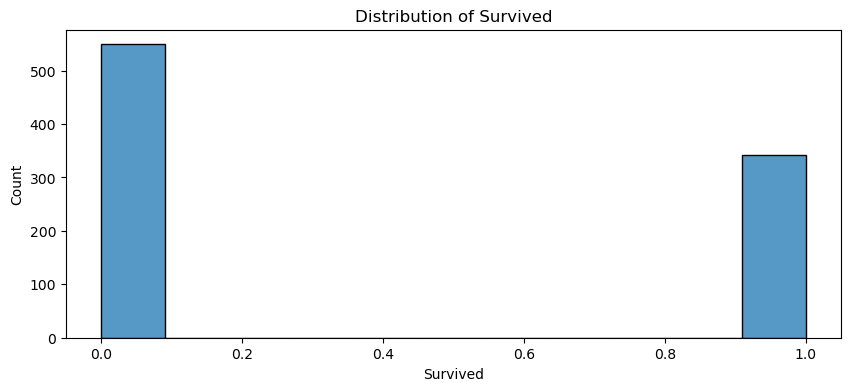

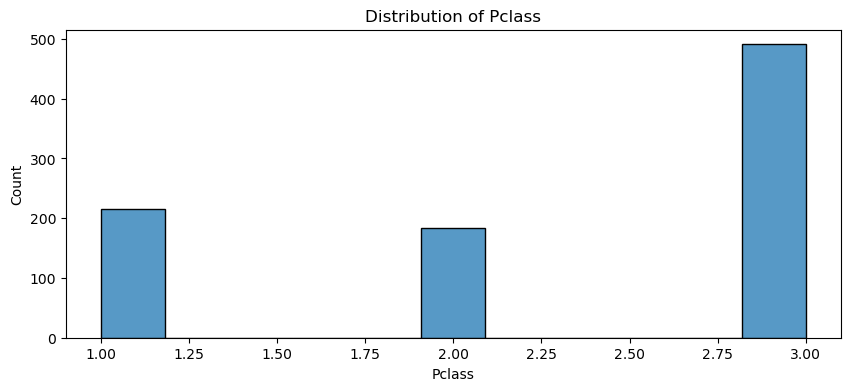

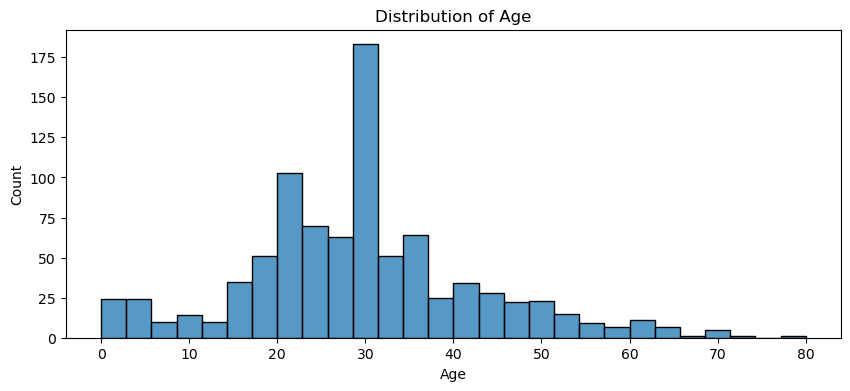

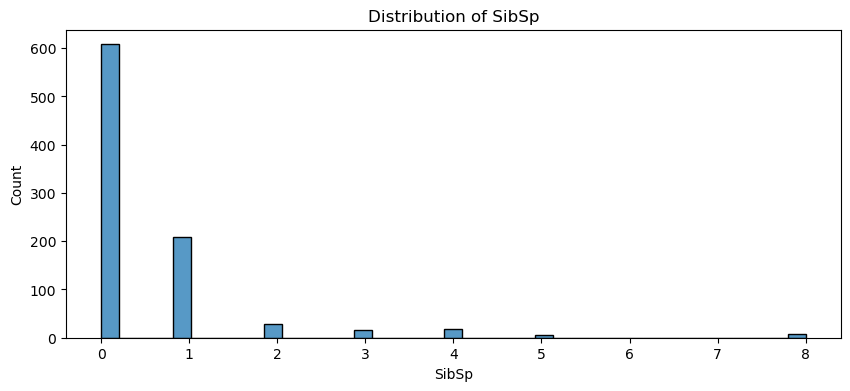

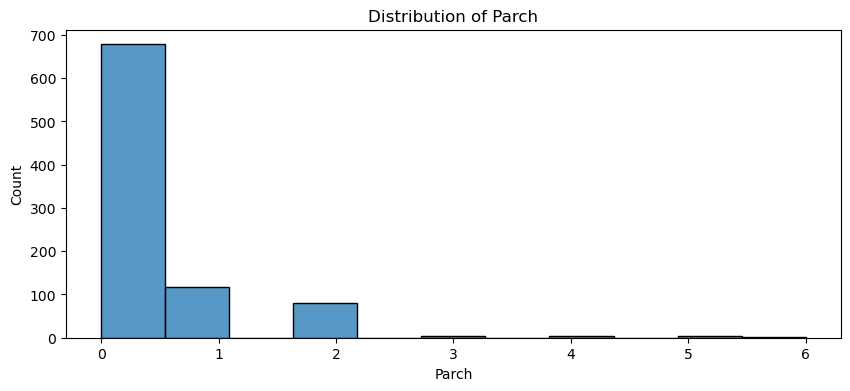

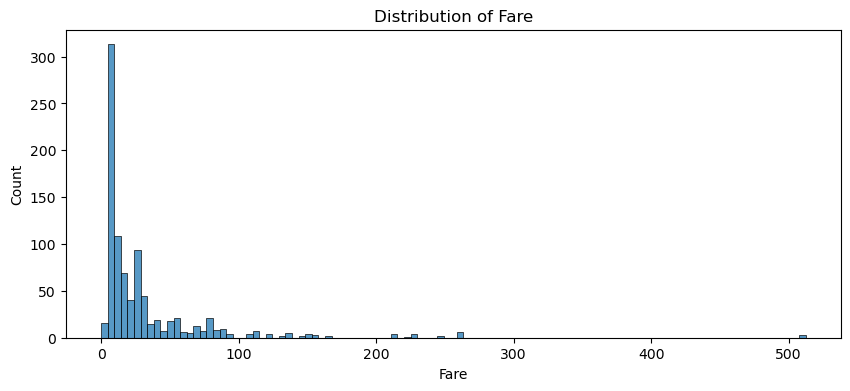

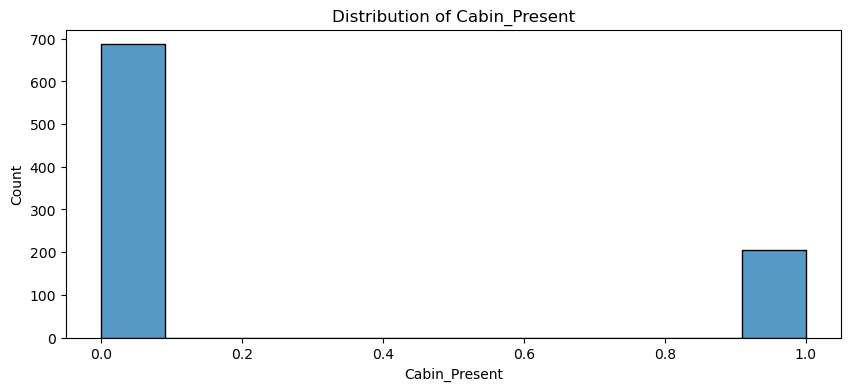

In [30]:
for i in num:
    plt.figure(figsize=(10,4))
    sns.histplot(x=df1[i],data=df1)
    plt.title(f'Distribution of {i}')
    plt.show()

# Observation:
    From the graph, Age is distributed normally.
    Fare distribution has some skewness.
    Other columns in Numeric type dtype of Integer lies between 0 to 6.`

In [31]:
df1.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Title', 'Cabin_Present'],
      dtype='object')

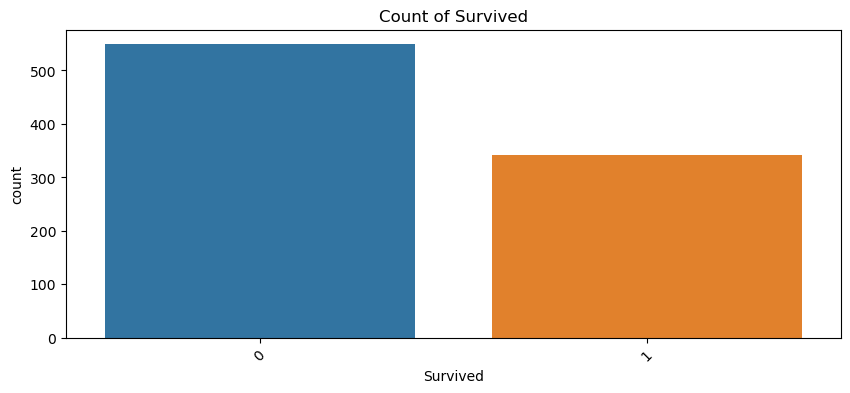

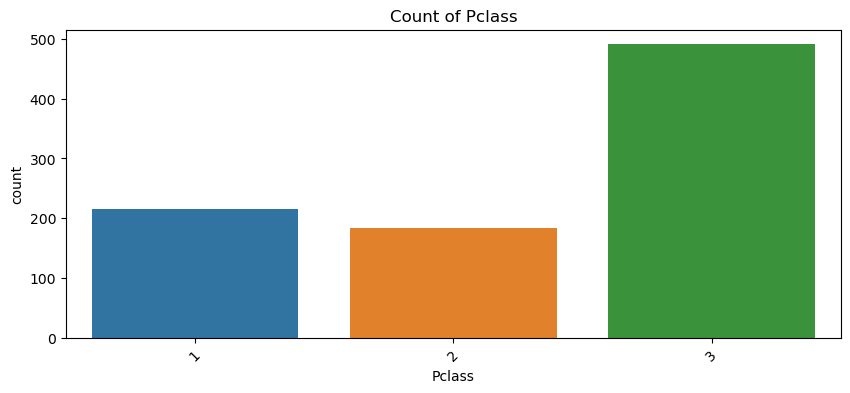

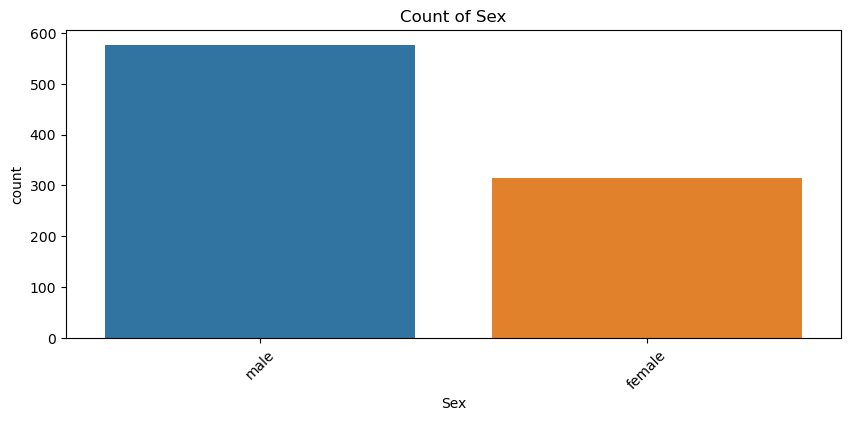

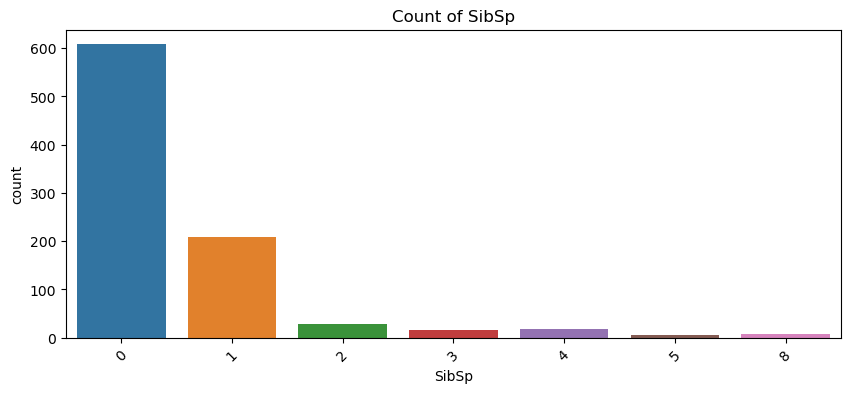

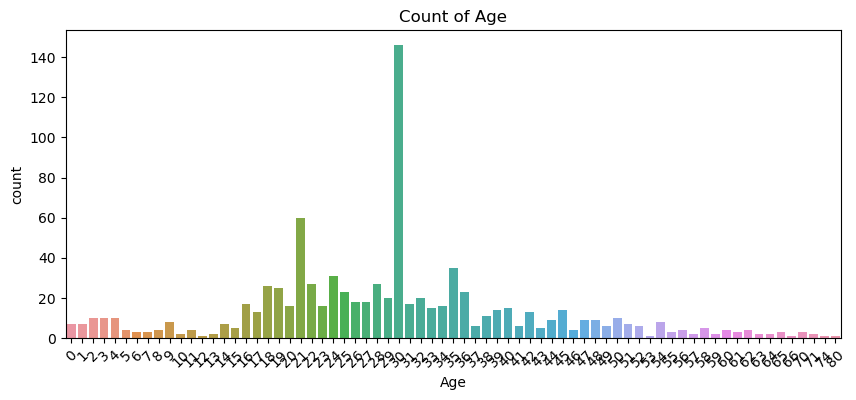

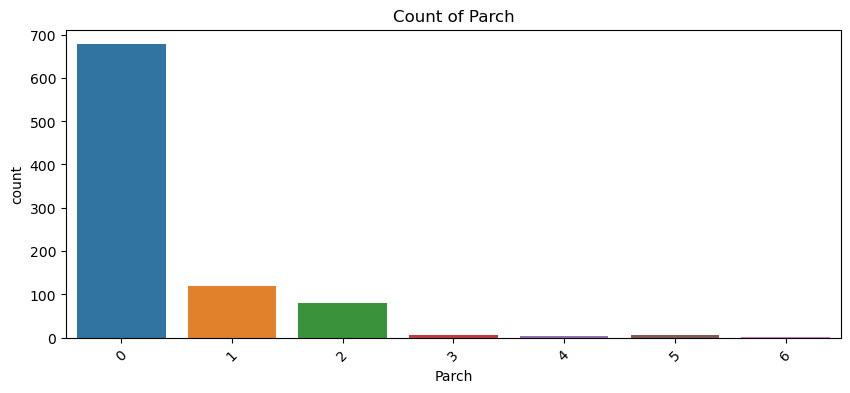

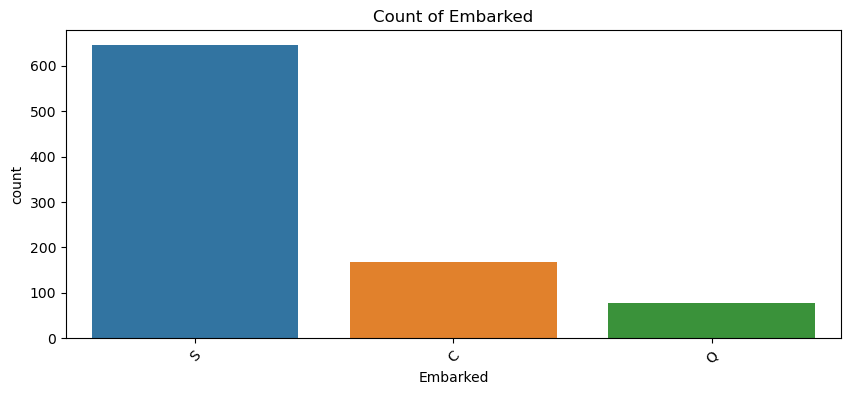

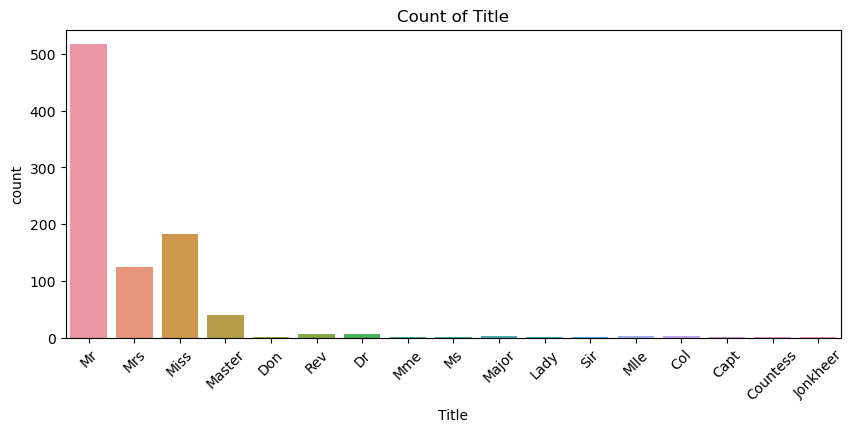

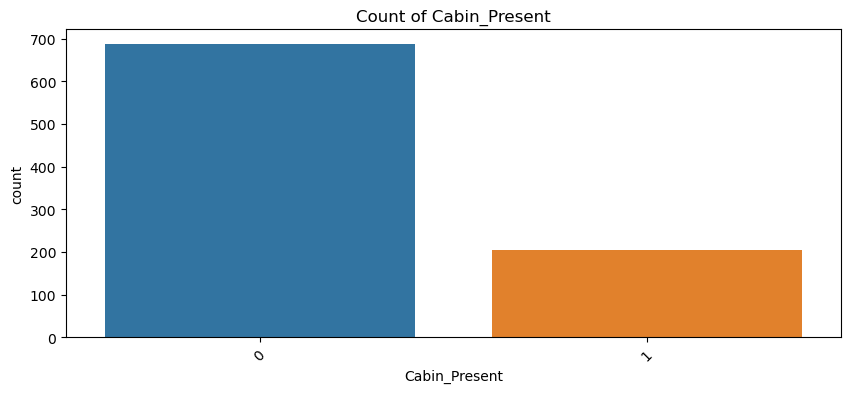

In [32]:
for i in ['Survived', 'Pclass','Sex','SibSp','Age',
       'Parch', 'Embarked', 'Title', 'Cabin_Present']:
    plt.figure(figsize=(10,4))
    sns.countplot(x=df1[i],data=df1)
    plt.xticks(rotation=45)
    plt.title(f'Count of {i}')
    plt.show()

# Observation:
    From the graph:
        1. No. of people survived is less and more no. of counts ends in death(as death count gone more than 500).
        2. Most no. of passenger travelled in 3rd class and followed by 1st class and then 2nd class respectively.
        3. Male gender is more than female travelled in the ship.
        4.There people travelled with their spouse and sibiling, most of the case they didn't travelled with this category.
        5.Similarly people travelled with parents and children but most cases not with this category too.
        6.From the section Age, most people lies in the age above 30 and senior citizen is less in count.
        7.From the graph of Embarked, most of them from Chebourg followed by Queenstown and Southampton.
        8.So from the title graph, most of them male which we discussed in Age section that most lies in age above 30,followed by other ages,
    

In [33]:
df1.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin_Present
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.371493,0.523008,0.381594,32.204208,0.228956
std,0.486592,0.836071,13.277422,1.102743,0.806057,49.693429,0.420397
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,21.000000,0.000000,0.000000,7.910400,0.000000
50%,0.000000,3.000000,30.000000,0.000000,0.000000,14.454200,0.000000
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,0.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


Survived            AxesSubplot(0.125,0.53;0.0824468x0.35)
Pclass           AxesSubplot(0.223936,0.53;0.0824468x0.35)
Age              AxesSubplot(0.322872,0.53;0.0824468x0.35)
SibSp            AxesSubplot(0.421809,0.53;0.0824468x0.35)
Parch            AxesSubplot(0.520745,0.53;0.0824468x0.35)
Fare             AxesSubplot(0.619681,0.53;0.0824468x0.35)
Cabin_Present    AxesSubplot(0.718617,0.53;0.0824468x0.35)
dtype: object

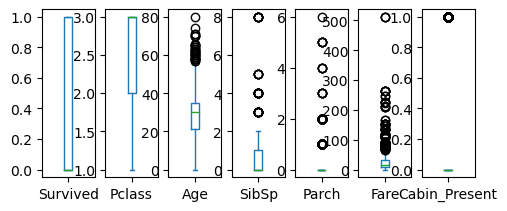

In [34]:
df1.plot(kind='box',subplots=True,layout=(2,8))

# Observation:
    Most Outlier present in Age and Fare features as we can see from the box plot of each columns.

# BiVariate

In [35]:
df1.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Title', 'Cabin_Present'],
      dtype='object')

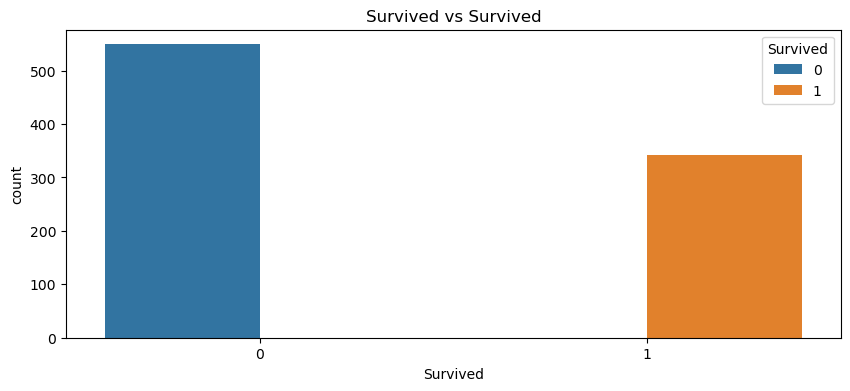

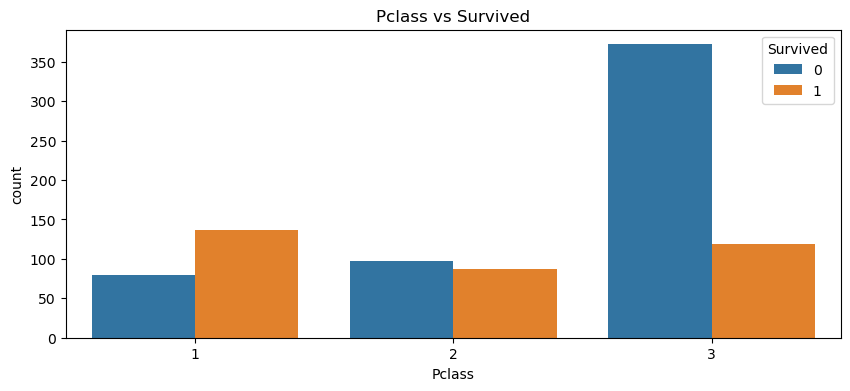

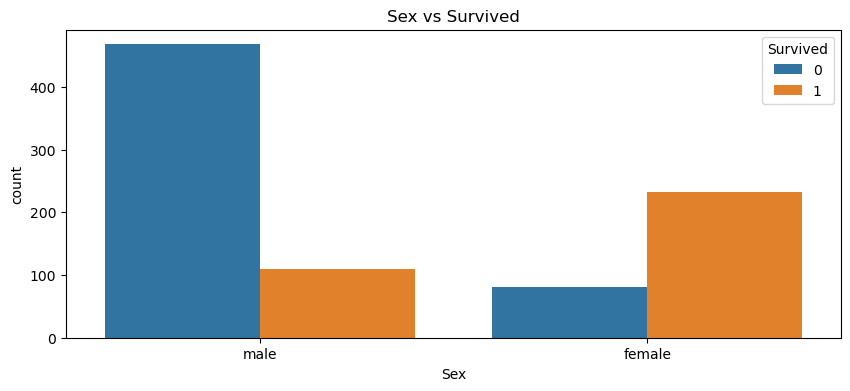

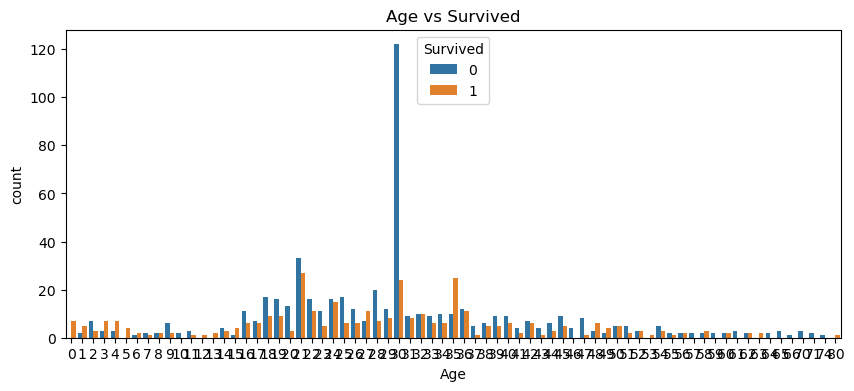

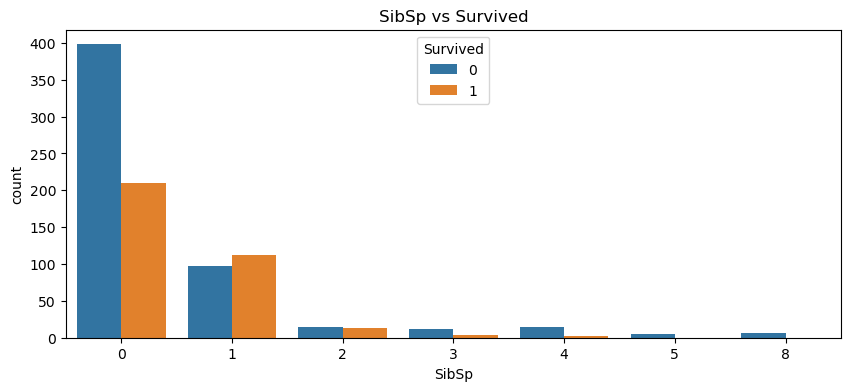

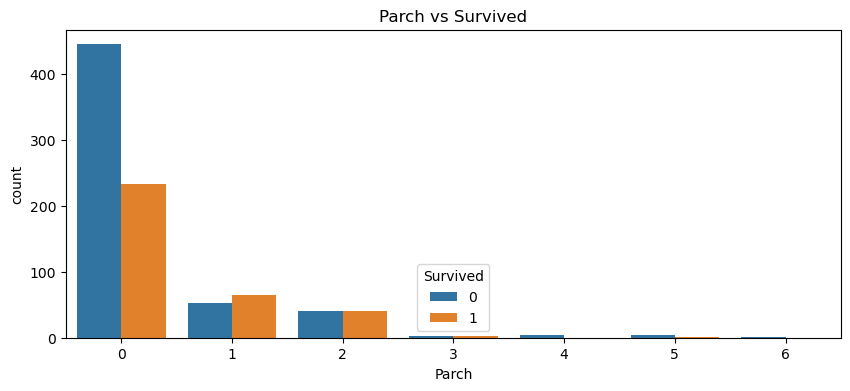

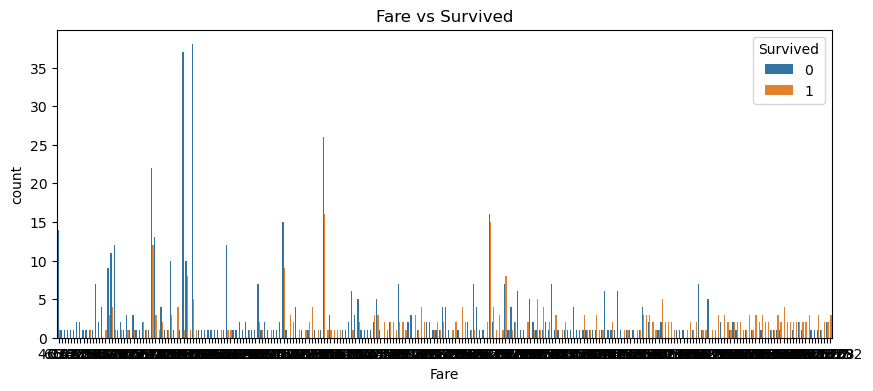

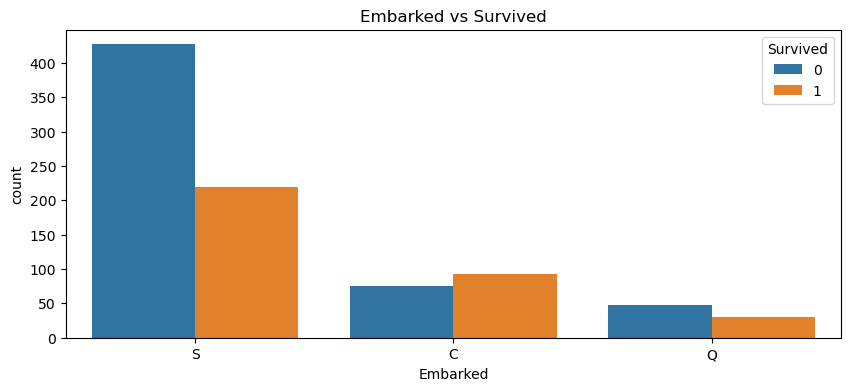

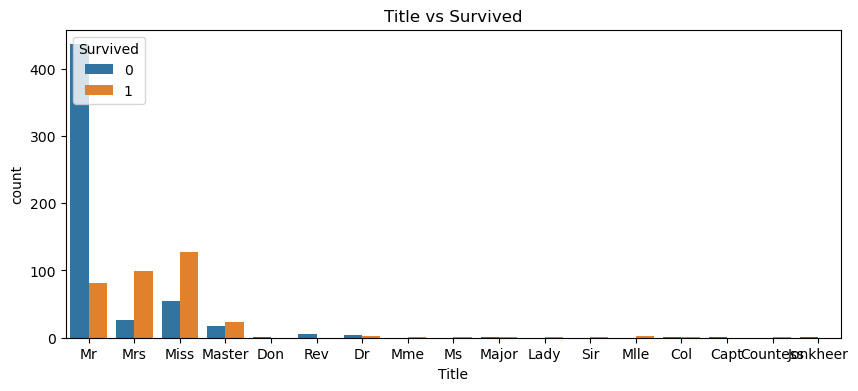

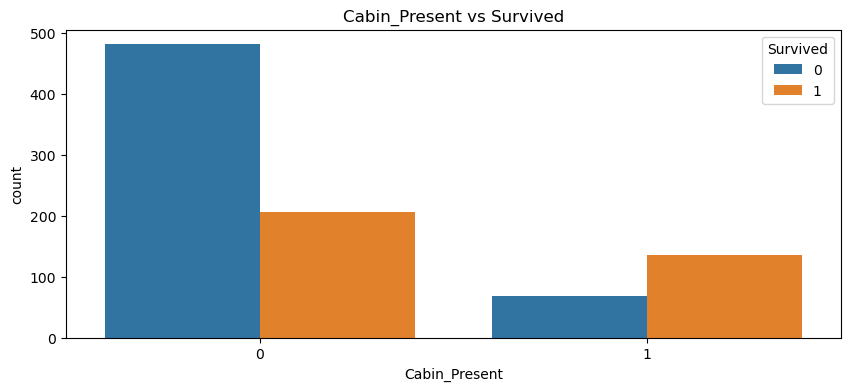

In [36]:
for i in df1.columns:
    plt.figure(figsize=(10,4))
    sns.countplot(x=df[i],hue='Survived',data=df1)
    plt.title(f'{i} vs Survived')
    plt.show()

# Observation:
    From this Bivariate graph:
        1.Most no. of people survived in 1st class and most no. of people passed away in 3rd class.
        2.From the sex vs survived graph, it tells clearly more of people survived from female and childrens.
        3.From Age wise, people above 30 passed away.
        4.People who has 0 sibiling/spouse has survived more and also lies in Parents/children category
        5.Most people who travelled from Southampton has more death.
        6.From the graph Title vs Survived,Mr. category as majore death happened and followed by others.
        7.People doesnt in cabin met many death from the visual of Cabin_Present vs Survived.

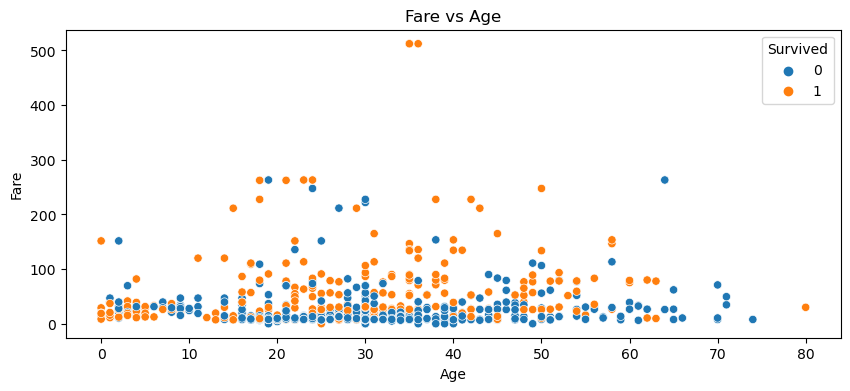

In [37]:
plt.figure(figsize=(10,4))
sns.scatterplot(y='Fare',x='Age',hue='Survived',data=df1)
plt.title(f'Fare vs Age')
plt.show()

# Observation:
    Fare values of the ages is not depends on the target variable.
    

In [38]:
df1.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Title', 'Cabin_Present'],
      dtype='object')

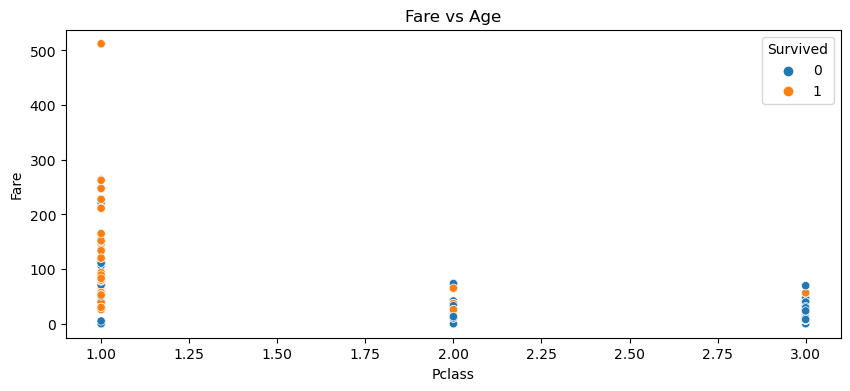

In [39]:
plt.figure(figsize=(10,4))
sns.scatterplot(y='Fare',x='Pclass',hue='Survived',data=df1)
plt.title(f'Fare vs Age')
plt.show()

# Multivariate

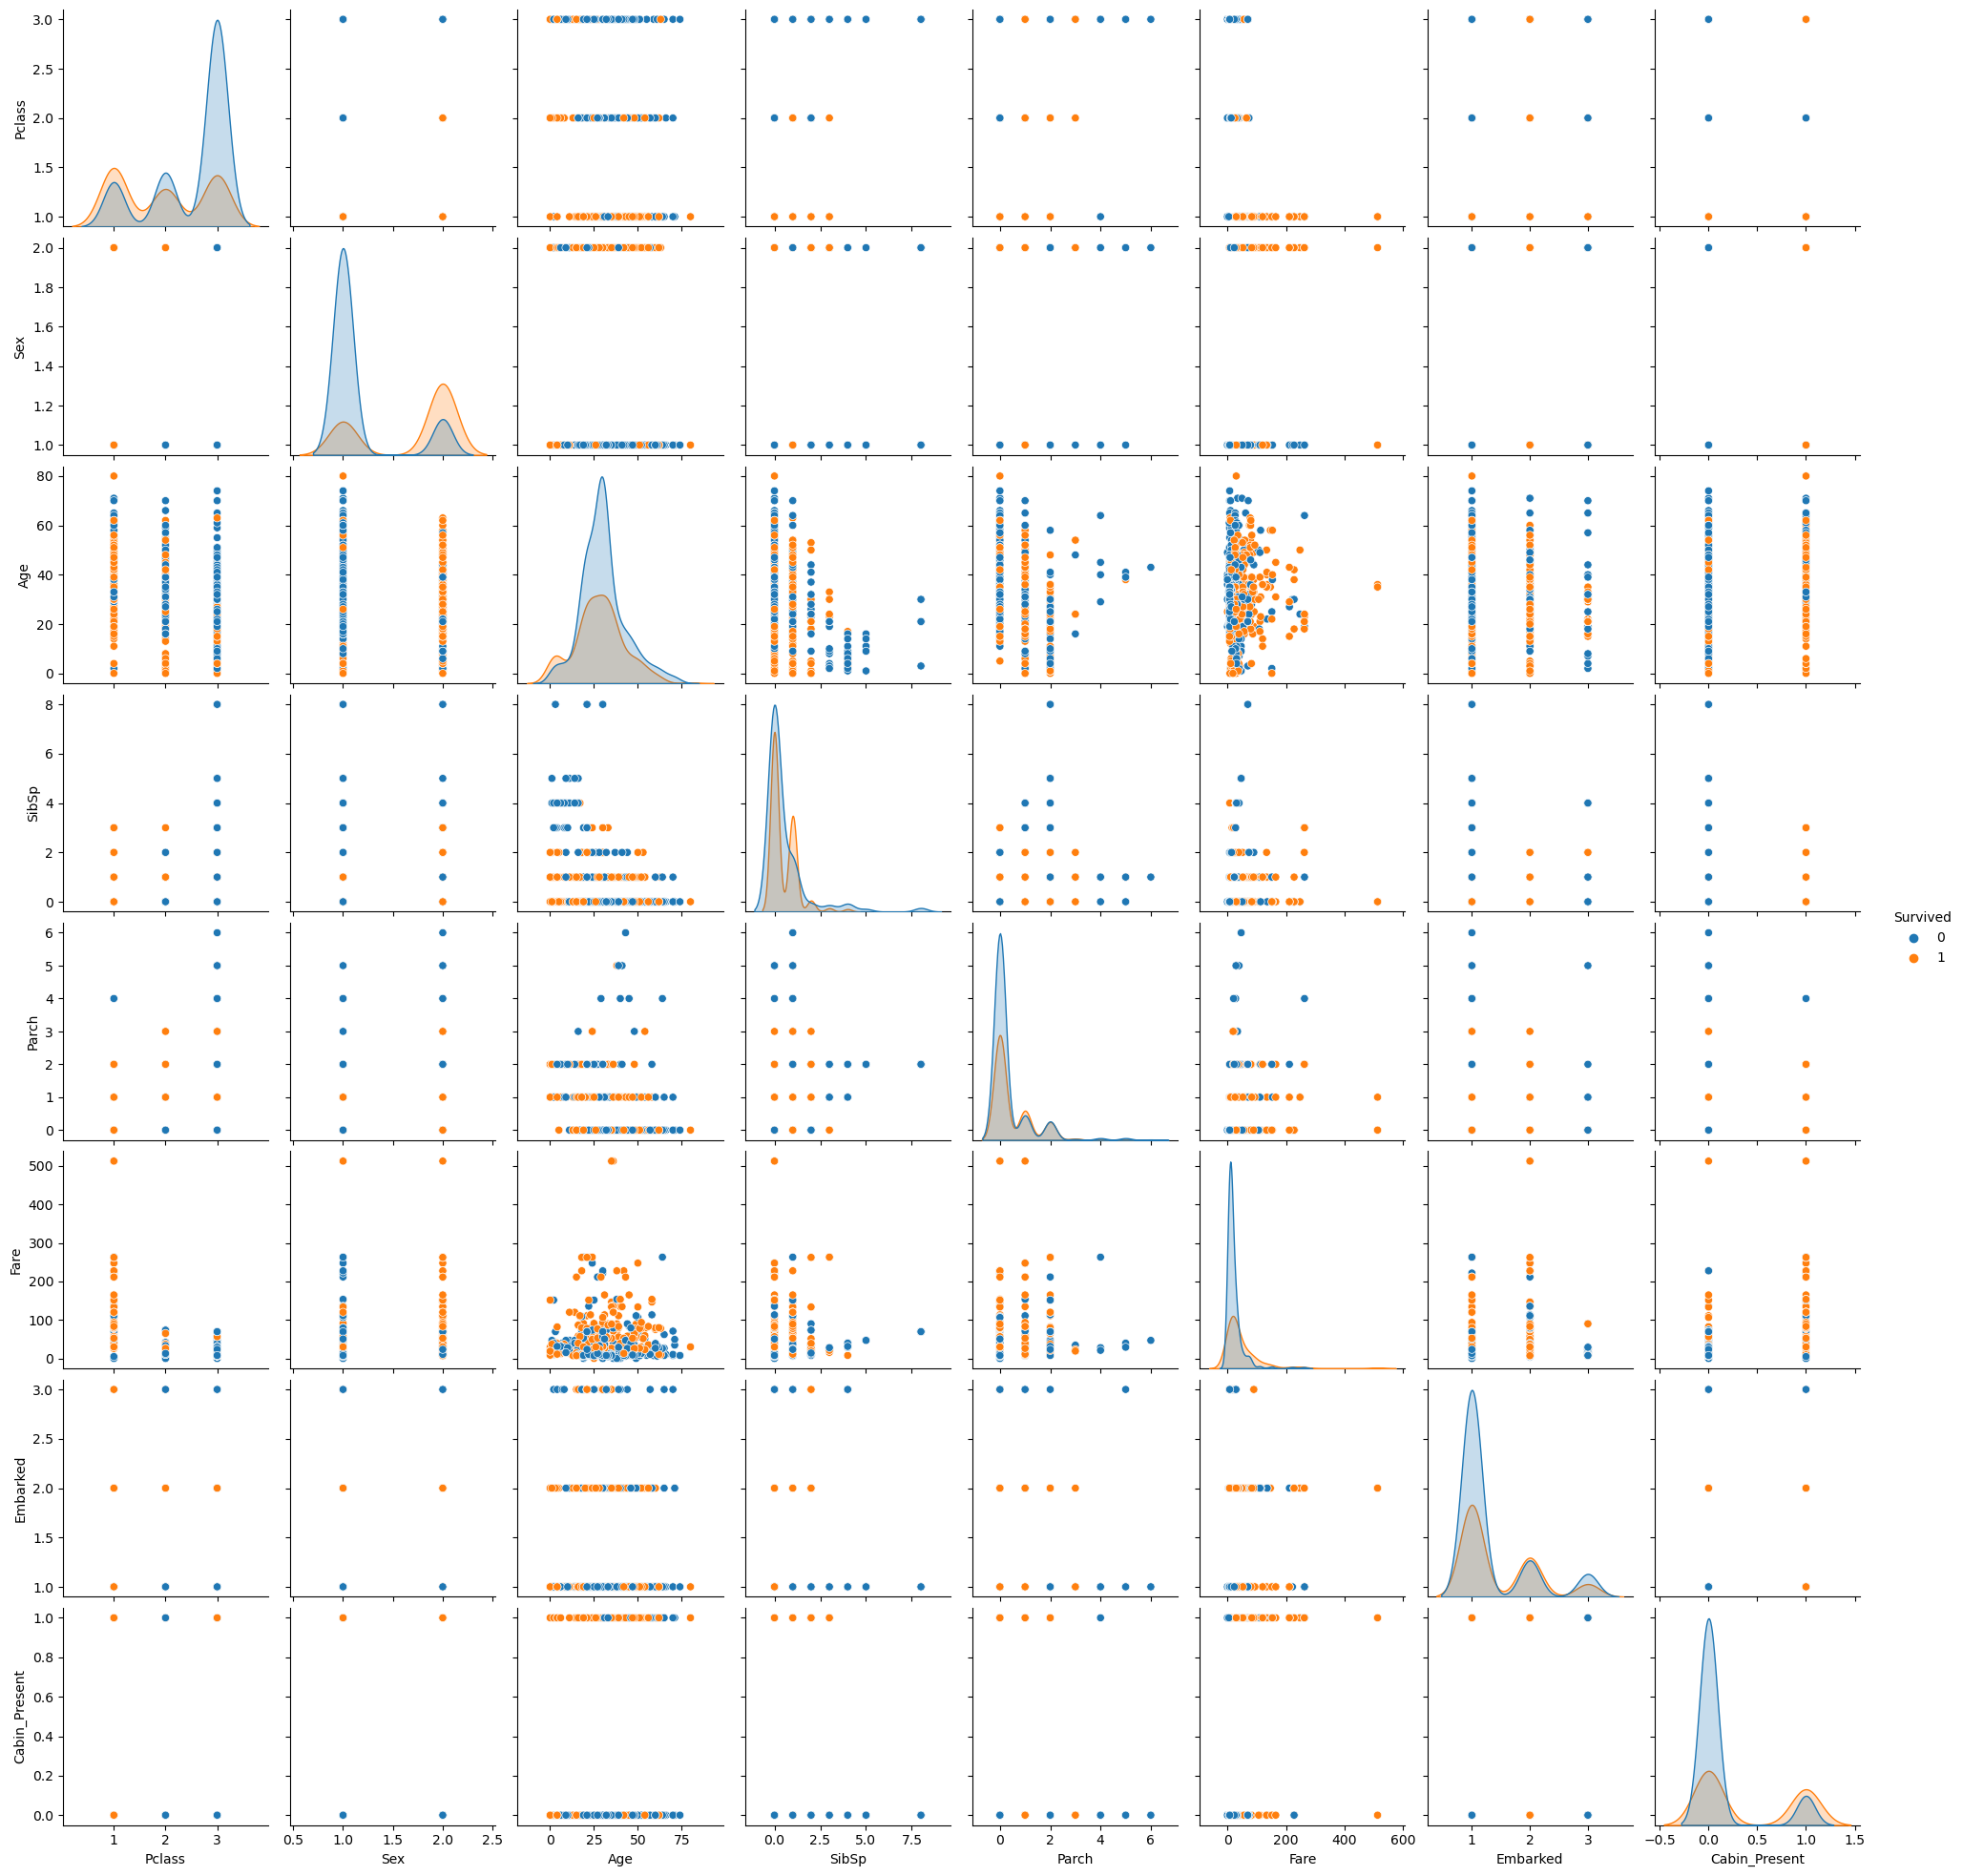

In [107]:
sns.pairplot(df1,hue='Survived')

In [41]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Sex            891 non-null    object 
 3   Age            891 non-null    int64  
 4   SibSp          891 non-null    int64  
 5   Parch          891 non-null    int64  
 6   Fare           891 non-null    float64
 7   Embarked       891 non-null    object 
 8   Title          891 non-null    object 
 9   Cabin_Present  891 non-null    int32  
dtypes: float64(1), int32(1), int64(5), object(3)
memory usage: 66.3+ KB


In [42]:
df1.Sex.unique()

array(['male', 'female'], dtype=object)

In [43]:
df1.Sex=df1.Sex.map({'male':1,'female':2})

C:\Users\ganes\AppData\Local\Temp\ipykernel_14748\3640235882.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.Sex=df1.Sex.map({'male':1,'female':2})


In [44]:
df1.Sex.unique()

array([1, 2], dtype=int64)

In [47]:
df1.Embarked.unique()

array(['S', 'C', 'Q'], dtype=object)

In [48]:
df1.Embarked=df1.Embarked.map({'S':1,'C':2,'Q':3})

C:\Users\ganes\AppData\Local\Temp\ipykernel_14748\2718989483.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.Embarked=df1.Embarked.map({'S':1,'C':2,'Q':3})


In [49]:
df1.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Title', 'Cabin_Present'],
      dtype='object')

In [50]:
df2=df1[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', #'Title', 
         'Cabin_Present']]

# Remove Outliers

# 

In [45]:
from scipy.stats import zscore

In [51]:
z=np.abs(zscore(df2))
z

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin_Present
0,0.789272,0.827377,0.737695,0.555502,0.432793,0.473674,0.502445,0.568837,0.544925
1,1.266990,1.566107,1.355574,0.650228,0.432793,0.473674,0.786845,1.005181,1.835115
2,1.266990,0.827377,1.355574,0.254069,0.474545,0.473674,0.488854,0.568837,0.544925
3,1.266990,1.566107,1.355574,0.424154,0.432793,0.473674,0.420730,0.568837,1.835115
4,0.789272,0.827377,0.737695,0.424154,0.474545,0.473674,0.486337,0.568837,0.544925
...,...,...,...,...,...,...,...,...,...
886,0.789272,0.369365,0.737695,0.178711,0.474545,0.473674,0.386671,0.568837,0.544925
887,1.266990,1.566107,1.355574,0.781576,0.474545,0.473674,0.044381,0.568837,1.835115
888,0.789272,0.827377,1.355574,0.630860,0.432793,2.008933,0.176263,0.568837,0.544925
889,1.266990,1.566107,0.737695,0.254069,0.474545,0.473674,0.044381,1.005181,1.835115


In [52]:
threshold=3
print(np.where(z>3))

(array([ 13,  16,  25,  27,  50,  59,  68,  71,  86,  88,  96, 116, 118,
       119, 159, 164, 167, 171, 180, 182, 201, 233, 258, 261, 266, 278,
       299, 311, 324, 341, 360, 377, 380, 386, 437, 438, 438, 480, 493,
       527, 541, 542, 557, 567, 610, 630, 638, 672, 678, 679, 683, 686,
       689, 700, 716, 730, 736, 737, 742, 745, 774, 779, 787, 792, 813,
       824, 846, 850, 851, 858, 863, 885], dtype=int64), array([5, 4, 5, 6, 4, 4, 4, 4, 5, 6, 3, 3, 6, 4, 4, 4, 5, 4, 4, 4, 4, 4,
       6, 4, 4, 4, 6, 6, 4, 6, 5, 6, 6, 4, 5, 5, 6, 4, 3, 6, 4, 4, 6, 5,
       5, 3, 5, 3, 5, 6, 4, 4, 6, 6, 6, 6, 5, 6, 6, 3, 5, 6, 4, 4, 4, 4,
       4, 4, 3, 5, 4, 5], dtype=int64))


In [53]:
z.iloc[13][6]

0.01870931177853076

In [54]:
df3=df2[(z<3).all (axis=1)]

In [55]:
df3.shape

(820, 9)

In [56]:
x=df3.drop(['Survived'],axis=1)

In [57]:
y=df3['Survived']

In [58]:
from imblearn.over_sampling import SMOTE

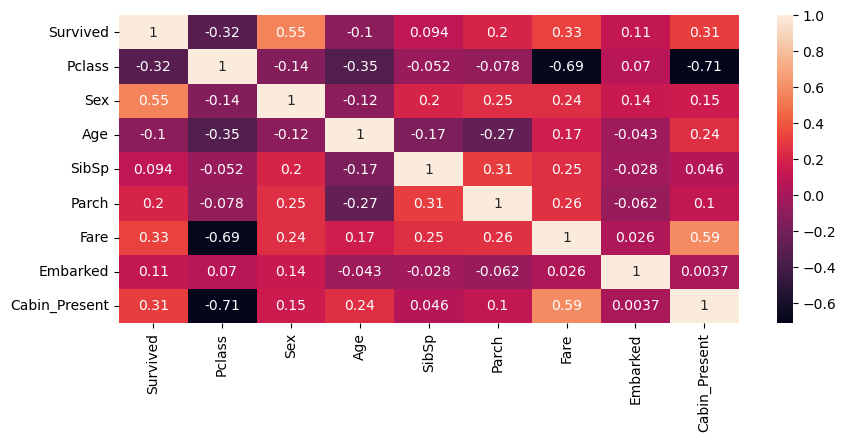

In [59]:
titanic_cor=df3.corr()
plt.figure(figsize=(10,4))
sns.heatmap(titanic_cor,annot=True)
plt.show()

# vif checks

In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [63]:
def vifcheck(x):
    vif=pd.DataFrame()
    vif['Variable']=x.columns
    vif['VIF']=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
    print(vif)

In [64]:
vifcheck(x)

        Variable       VIF
0         Pclass  9.169194
1            Sex  9.051326
2            Age  5.854721
3          SibSp  1.574257
4          Parch  1.552536
5           Fare  3.576742
6       Embarked  5.776010
7  Cabin_Present  2.407374


In [65]:
smt=SMOTE()
x_sampled,y_sampled=smt.fit_resample(x,y)

In [66]:
y_sampled.value_counts()

0    500
1    500
Name: Survived, dtype: int64

# Model:

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,200):
    x_train,x_test,y_train,y_test=train_test_split(x_sampled,y_sampled,test_size=.30,random_state=i)
    rf=RandomForestClassifier()
    rf.fit(x_train,y_train)
    pred=rf.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.8566666666666667 and randomstate is75


# Scenario:1 Removed Outliers

In [80]:
x1_train,x1_test,y1_train,y1_test=train_test_split(x_sampled,y_sampled,test_size=.30,random_state=75)

# Model:LogisticRegression

In [82]:
from sklearn.linear_model import LogisticRegression
lr1=LogisticRegression()
lr1.fit(x1_train,y1_train)
pred_lr1=lr1.predict(x1_test)

print('Accuracy:',accuracy_score(y1_test,pred_lr1))
print('Confusion_matrix:',confusion_matrix(y1_test,pred_lr1))
print('Classification_report:',classification_report(y1_test,pred_lr1))

Accuracy: 0.8066666666666666
Confusion_matrix: [[129  19]
 [ 39 113]]
Classification_report:               precision    recall  f1-score   support

           0       0.77      0.87      0.82       148
           1       0.86      0.74      0.80       152

    accuracy                           0.81       300
   macro avg       0.81      0.81      0.81       300
weighted avg       0.81      0.81      0.81       300



C:\Users\ganes\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [84]:
from sklearn.model_selection import train_test_split,cross_val_score

In [86]:
lr1_cross_score=cross_val_score(lr1,x_sampled,y_sampled,cv=5)
print(lr1_cross_score)
print(lr1_cross_score.mean())
print('Difference between Accuracy and cross_value',((accuracy_score(y1_test,pred_lr1))-(lr1_cross_score.mean())))

[0.75  0.79  0.765 0.78  0.745]
0.766
Difference between Accuracy and cross_value 0.04066666666666663


C:\Users\ganes\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ganes\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

# Model:DecisionTreeClassifier

In [92]:
from sklearn.tree import DecisionTreeClassifier

In [93]:
dtc1=DecisionTreeClassifier()
dtc1.fit(x1_train,y1_train)
pred_dtc1=dtc1.predict(x1_test)

In [94]:
print('Accuracy:',accuracy_score(y1_test,pred_dtc1))
print('Confusion_matrix:',confusion_matrix(y1_test,pred_dtc1))
print('Classification_report:',classification_report(y1_test,pred_dtc1))

Accuracy: 0.81
Confusion_matrix: [[117  31]
 [ 26 126]]
Classification_report:               precision    recall  f1-score   support

           0       0.82      0.79      0.80       148
           1       0.80      0.83      0.82       152

    accuracy                           0.81       300
   macro avg       0.81      0.81      0.81       300
weighted avg       0.81      0.81      0.81       300



In [95]:
dtc1_cross_score=cross_val_score(dtc1,x_sampled,y_sampled,cv=5)
print(dtc1_cross_score)
print(dtc1_cross_score.mean())
print('Difference between Accuracy and cross_value',((accuracy_score(y1_test,pred_dtc1))-(dtc1_cross_score.mean())))

[0.725 0.75  0.775 0.795 0.765]
0.762
Difference between Accuracy and cross_value 0.04800000000000004


# Model:KNN

In [97]:
knn1=KNeighborsClassifier()
knn1.fit(x1_train,y1_train)

KNeighborsClassifier()

In [98]:
pred_knn1=knn1.predict(x1_test)

In [99]:
print('Accuracy:',accuracy_score(y1_test,pred_knn1))
print('Confusion_matrix:',confusion_matrix(y1_test,pred_knn1))
print('Classification_report:',classification_report(y1_test,pred_knn1))

Accuracy: 0.79
Confusion_matrix: [[113  35]
 [ 28 124]]
Classification_report:               precision    recall  f1-score   support

           0       0.80      0.76      0.78       148
           1       0.78      0.82      0.80       152

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.79      0.79      0.79       300



In [100]:
knn1_cross_score=cross_val_score(knn1,x_sampled,y_sampled,cv=5)
print(knn1_cross_score)
print(knn1_cross_score.mean())
print('Difference between Accuracy and cross_value',((accuracy_score(y1_test,pred_knn1))-(knn1_cross_score.mean())))

[0.665 0.68  0.81  0.75  0.765]
0.7340000000000001
Difference between Accuracy and cross_value 0.05599999999999994


# Model:SVM

In [102]:
from sklearn.svm import SVC

In [103]:
svc1=SVC()
svc1.fit(x1_train,y1_train)

SVC()

In [104]:
pred_svc1=svc1.predict(x1_test)

In [105]:
print('Accuracy:',accuracy_score(y1_test,pred_svc1))
print('Confusion_matrix:',confusion_matrix(y1_test,pred_svc1))
print('Classification_report:',classification_report(y1_test,pred_svc1))

Accuracy: 0.7066666666666667
Confusion_matrix: [[119  29]
 [ 59  93]]
Classification_report:               precision    recall  f1-score   support

           0       0.67      0.80      0.73       148
           1       0.76      0.61      0.68       152

    accuracy                           0.71       300
   macro avg       0.72      0.71      0.70       300
weighted avg       0.72      0.71      0.70       300



In [106]:
svc1_cross_score=cross_val_score(svc1,x_sampled,y_sampled,cv=5)
print(svc1_cross_score)
print(svc1_cross_score.mean())
print('Difference between Accuracy and cross_value',((accuracy_score(y1_test,pred_svc1))-(svc1_cross_score.mean())))

[0.555 0.71  0.75  0.73  0.68 ]
0.685
Difference between Accuracy and cross_value 0.021666666666666612


# Model:SVM(Linear)

In [108]:
svc_lin1=SVC(kernel='linear')
svc_lin1.fit(x1_train,y1_train)

SVC(kernel='linear')

In [109]:
pred_svc_lin1=svc_lin1.predict(x1_test)

In [110]:
print('Accuracy:',accuracy_score(y1_test,pred_svc_lin1))
print('Confusion_matrix:',confusion_matrix(y1_test,pred_svc_lin1))
print('Classification_report:',classification_report(y1_test,pred_svc_lin1))

Accuracy: 0.78
Confusion_matrix: [[127  21]
 [ 45 107]]
Classification_report:               precision    recall  f1-score   support

           0       0.74      0.86      0.79       148
           1       0.84      0.70      0.76       152

    accuracy                           0.78       300
   macro avg       0.79      0.78      0.78       300
weighted avg       0.79      0.78      0.78       300



In [111]:
svc_lin1_cross_score=cross_val_score(svc_lin1,x_sampled,y_sampled,cv=5)
print(svc_lin1_cross_score)
print(svc_lin1_cross_score.mean())
print('Difference between Accuracy and cross_value',((accuracy_score(y1_test,pred_svc_lin1))-(svc_lin1_cross_score.mean())))

[0.75  0.785 0.705 0.76  0.7  ]
0.74
Difference between Accuracy and cross_value 0.040000000000000036


# Model:SVM(poly)

In [112]:
svc_pol1=SVC(kernel='poly')
svc_pol1.fit(x1_train,y1_train)

SVC(kernel='poly')

In [113]:
pred_svc_pol1=svc_pol1.predict(x1_test)

In [115]:
print('Accuracy:',accuracy_score(y1_test,pred_svc_pol1))
print('Confusion_matrix:',confusion_matrix(y1_test,pred_svc_pol1))
print('Classification_report:',classification_report(y1_test,pred_svc_pol1))

Accuracy: 0.62
Confusion_matrix: [[140   8]
 [106  46]]
Classification_report:               precision    recall  f1-score   support

           0       0.57      0.95      0.71       148
           1       0.85      0.30      0.45       152

    accuracy                           0.62       300
   macro avg       0.71      0.62      0.58       300
weighted avg       0.71      0.62      0.58       300



# Model:RandomForestClassifier

In [116]:
rf1=RandomForestClassifier()
rf1.fit(x1_train,y1_train)

RandomForestClassifier()

In [117]:
pred_rf1=rf1.predict(x1_test)

In [119]:
print('Accuracy:',accuracy_score(y1_test,pred_rf1))
print('Confusion_matrix:',confusion_matrix(y1_test,pred_rf1))
print('Classification_report:',classification_report(y1_test,pred_rf1))

Accuracy: 0.84
Confusion_matrix: [[123  25]
 [ 23 129]]
Classification_report:               precision    recall  f1-score   support

           0       0.84      0.83      0.84       148
           1       0.84      0.85      0.84       152

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300



In [120]:
rf1_cross_score=cross_val_score(rf1,x_sampled,y_sampled,cv=5)
print(rf1_cross_score)
print(rf1_cross_score.mean())
print('Difference between Accuracy and cross_value',((accuracy_score(y1_test,pred_rf1))-(rf1_cross_score.mean())))

[0.77  0.805 0.805 0.835 0.78 ]
0.799
Difference between Accuracy and cross_value 0.040999999999999925


# Model:ExtraTreeClassifier

In [122]:
from sklearn.ensemble import ExtraTreesClassifier

In [123]:
et1=ExtraTreesClassifier()
et1.fit(x1_train,y1_train)

ExtraTreesClassifier()

In [124]:
pred_et1=et1.predict(x1_test)

In [125]:
print('Accuracy:',accuracy_score(y1_test,pred_et1))
print('Confusion_matrix:',confusion_matrix(y1_test,pred_et1))
print('Classification_report:',classification_report(y1_test,pred_et1))

Accuracy: 0.84
Confusion_matrix: [[124  24]
 [ 24 128]]
Classification_report:               precision    recall  f1-score   support

           0       0.84      0.84      0.84       148
           1       0.84      0.84      0.84       152

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300



In [126]:
et1_cross_score=cross_val_score(et1,x_sampled,y_sampled,cv=5)
print(et1_cross_score)
print(et1_cross_score.mean())
print('Difference between Accuracy and cross_value',((accuracy_score(y1_test,pred_et1))-(et1_cross_score.mean())))

[0.745 0.775 0.805 0.825 0.785]
0.7870000000000001
Difference between Accuracy and cross_value 0.052999999999999825


# Model:AdaBoostClassifier

In [127]:
from sklearn.ensemble import AdaBoostClassifier

In [129]:
ada1=AdaBoostClassifier(algorithm='SAMME')
ada1.fit(x1_train,y1_train)

AdaBoostClassifier(algorithm='SAMME')

In [130]:
pred_ada1=ada1.predict(x1_test)

In [131]:
print('Accuracy:',accuracy_score(y1_test,pred_ada1))
print('Confusion_matrix:',confusion_matrix(y1_test,pred_ada1))
print('Classification_report:',classification_report(y1_test,pred_ada1))

Accuracy: 0.81
Confusion_matrix: [[124  24]
 [ 33 119]]
Classification_report:               precision    recall  f1-score   support

           0       0.79      0.84      0.81       148
           1       0.83      0.78      0.81       152

    accuracy                           0.81       300
   macro avg       0.81      0.81      0.81       300
weighted avg       0.81      0.81      0.81       300



In [134]:
ada1_cross_score=cross_val_score(ada1,x_sampled,y_sampled,cv=5)
print(ada1_cross_score)
print(ada1_cross_score.mean())
print('Difference between Accuracy and cross_value',((accuracy_score(y1_test,pred_ada1))-(ada1_cross_score.mean())))

[0.715 0.765 0.78  0.78  0.73 ]
0.754
Difference between Accuracy and cross_value 0.05600000000000005


# Model:GradientBoostingClassifier

In [136]:
from sklearn.ensemble import GradientBoostingClassifier

In [137]:
gb1=GradientBoostingClassifier()
gb1.fit(x1_train,y1_train)

GradientBoostingClassifier()

In [138]:
pred_gb1=gb1.predict(x1_test)

In [139]:
print('Accuracy:',accuracy_score(y1_test,pred_gb1))
print('Confusion_matrix:',confusion_matrix(y1_test,pred_gb1))
print('Classification_report:',classification_report(y1_test,pred_gb1))

Accuracy: 0.8266666666666667
Confusion_matrix: [[127  21]
 [ 31 121]]
Classification_report:               precision    recall  f1-score   support

           0       0.80      0.86      0.83       148
           1       0.85      0.80      0.82       152

    accuracy                           0.83       300
   macro avg       0.83      0.83      0.83       300
weighted avg       0.83      0.83      0.83       300



In [140]:
gb1_cross_score=cross_val_score(gb1,x_sampled,y_sampled,cv=5)
print(gb1_cross_score)
print(gb1_cross_score.mean())
print('Difference between Accuracy and cross_value',((accuracy_score(y1_test,pred_gb1))-(gb1_cross_score.mean())))

[0.785 0.835 0.825 0.84  0.78 ]
0.8130000000000001
Difference between Accuracy and cross_value 0.013666666666666605


# Scenario:2 Without removing outliers

In [141]:
x1=df2.drop(['Survived'],axis=1)

In [142]:
y1=df2['Survived']

In [143]:
smt1=SMOTE()
x1_sampled,y1_sampled=smt1.fit_resample(x1,y1)

In [144]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,200):
    x_train,x_test,y_train,y_test=train_test_split(x1_sampled,y1_sampled,test_size=.30,random_state=i)
    rf=RandomForestClassifier()
    rf.fit(x_train,y_train)
    pred=rf.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.8545454545454545 and randomstate is16


In [145]:
x2_train,x2_test,y2_train,y2_test=train_test_split(x1_sampled,y1_sampled,test_size=.30,random_state=16)

In [ ]:
Model:LogisticRegression()

In [146]:
lr2=LogisticRegression()
lr2.fit(x2_train,y2_train)
pred_lr2=lr2.predict(x2_test)

C:\Users\ganes\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [147]:
print('Accuracy:',accuracy_score(y2_test,pred_lr2))
print('Confusion_matrix:',confusion_matrix(y2_test,pred_lr2))
print('Classification_report:',classification_report(y2_test,pred_lr2))

Accuracy: 0.796969696969697
Confusion_matrix: [[131  32]
 [ 35 132]]
Classification_report:               precision    recall  f1-score   support

           0       0.79      0.80      0.80       163
           1       0.80      0.79      0.80       167

    accuracy                           0.80       330
   macro avg       0.80      0.80      0.80       330
weighted avg       0.80      0.80      0.80       330



In [148]:
lr2_cross_score=cross_val_score(lr2,x1_sampled,y1_sampled,cv=5)
print(lr2_cross_score)
print(lr2_cross_score.mean())
print('Difference between Accuracy and cross_value',((accuracy_score(y2_test,pred_lr2))-(lr2_cross_score.mean())))

[0.75454545 0.79545455 0.76818182 0.78082192 0.72146119]
0.7640929846409298
Difference between Accuracy and cross_value 0.03287671232876721


C:\Users\ganes\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ganes\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

# Model:RandomForestClassifier

In [149]:
rf2=RandomForestClassifier()
rf2.fit(x2_train,y2_train)

RandomForestClassifier()

In [150]:
pred_rf2=rf2.predict(x2_test)

In [151]:
print('Accuracy:',accuracy_score(y2_test,pred_rf2))
print('Confusion_matrix:',confusion_matrix(y2_test,pred_rf2))
print('Classification_report:',classification_report(y2_test,pred_rf2))

Accuracy: 0.8484848484848485
Confusion_matrix: [[142  21]
 [ 29 138]]
Classification_report:               precision    recall  f1-score   support

           0       0.83      0.87      0.85       163
           1       0.87      0.83      0.85       167

    accuracy                           0.85       330
   macro avg       0.85      0.85      0.85       330
weighted avg       0.85      0.85      0.85       330



In [152]:
rf2_cross_score=cross_val_score(rf2,x1_sampled,y1_sampled,cv=5)
print(rf2_cross_score)
print(rf2_cross_score.mean())
print('Difference between Accuracy and cross_value',((accuracy_score(y2_test,pred_rf2))-(rf2_cross_score.mean())))

[0.75909091 0.80909091 0.79090909 0.82191781 0.83105023]
0.8024117891241179
Difference between Accuracy and cross_value 0.046073059360730584


# Model:ExtraTreeClassifier

In [153]:
et2=ExtraTreesClassifier()
et2.fit(x2_train,y2_train)

ExtraTreesClassifier()

In [154]:
pred_et2=et2.predict(x2_test)

In [155]:
print('Accuracy:',accuracy_score(y2_test,pred_et2))
print('Confusion_matrix:',confusion_matrix(y2_test,pred_et2))
print('Classification_report:',classification_report(y2_test,pred_et2))

Accuracy: 0.8303030303030303
Confusion_matrix: [[139  24]
 [ 32 135]]
Classification_report:               precision    recall  f1-score   support

           0       0.81      0.85      0.83       163
           1       0.85      0.81      0.83       167

    accuracy                           0.83       330
   macro avg       0.83      0.83      0.83       330
weighted avg       0.83      0.83      0.83       330



In [158]:
et2_cross_score=cross_val_score(et2,x1_sampled,y1_sampled,cv=5)
print(et2_cross_score)
print(et2_cross_score.mean())
print('Difference between Accuracy and cross_value',((accuracy_score(y2_test,pred_et2))-(et2_cross_score.mean())))

[0.75454545 0.77272727 0.81363636 0.83105023 0.80821918]
0.796035699460357
Difference between Accuracy and cross_value 0.034267330842673305


# Model:GradientBoostingClassifier

In [156]:
gb2=GradientBoostingClassifier()
gb2.fit(x2_train,y2_train)

GradientBoostingClassifier()

In [157]:
pred_gb2=gb2.predict(x2_test)

In [159]:
print('Accuracy:',accuracy_score(y2_test,pred_gb2))
print('Confusion_matrix:',confusion_matrix(y2_test,pred_gb2))
print('Classification_report:',classification_report(y2_test,pred_gb2))

Accuracy: 0.8545454545454545
Confusion_matrix: [[141  22]
 [ 26 141]]
Classification_report:               precision    recall  f1-score   support

           0       0.84      0.87      0.85       163
           1       0.87      0.84      0.85       167

    accuracy                           0.85       330
   macro avg       0.85      0.85      0.85       330
weighted avg       0.85      0.85      0.85       330



In [160]:
gb2_cross_score=cross_val_score(gb2,x1_sampled,y1_sampled,cv=5)
print(gb2_cross_score)
print(gb2_cross_score.mean())
print('Difference between Accuracy and cross_value',((accuracy_score(y2_test,pred_gb2))-(gb2_cross_score.mean())))

[0.78636364 0.79090909 0.84545455 0.82648402 0.79908676]
0.809659609796596
Difference between Accuracy and cross_value 0.04488584474885848


# Scenario:3 

In [161]:
df4=df3

In [162]:
df4['Familysize']=df4['SibSp'] + df4['Parch'] + 1
df4['IsAlone']=(df4['Familysize']==1).astype(int)

C:\Users\ganes\AppData\Local\Temp\ipykernel_14748\3861951980.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['Familysize']=df4['SibSp'] + df4['Parch'] + 1
C:\Users\ganes\AppData\Local\Temp\ipykernel_14748\3861951980.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['IsAlone']=(df4['Familysize']==1).astype(int)


In [163]:
df4

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin_Present,Familysize,IsAlone
0,0,3,1,22,1,0,7.2500,1,0,2,0
1,1,1,2,38,1,0,71.2833,2,1,2,0
2,1,3,2,26,0,0,7.9250,1,0,1,1
3,1,1,2,35,1,0,53.1000,1,1,2,0
4,0,3,1,35,0,0,8.0500,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27,0,0,13.0000,1,0,1,1
887,1,1,2,19,0,0,30.0000,1,1,1,1
888,0,3,2,21,1,2,23.4500,1,0,4,0
889,1,1,1,26,0,0,30.0000,2,1,1,1


In [167]:
from sklearn.preprocessing import StandardScaler

In [169]:
std1=StandardScaler()
df4_scaled=pd.DataFrame(std1.fit_transform(df4),columns=df4.columns)

In [171]:
x3=df4_scaled.drop(['Survived','SibSp','Parch'],axis=1)

In [174]:
y3=df4['Survived']

In [175]:
smt3=SMOTE()
x3_sampled,y3_sampled=smt3.fit_resample(x3,y3)

In [180]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x3_sampled,y3_sampled,test_size=.30,random_state=i)
    rf=RandomForestClassifier()
    rf.fit(x_train,y_train)
    pred=rf.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')


Best Accuracy for the sampled date is 0.8733333333333333 and randomstate is151


In [178]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x3_sampled,y3_sampled,test_size=.30,random_state=i)
    gb=GradientBoostingClassifier()
    gb.fit(x_train,y_train)
    pred=gb.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.88 and randomstate is85


In [179]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x3_sampled,y3_sampled,test_size=.30,random_state=i)
    dtc=DecisionTreeClassifier()
    dtc.fit(x_train,y_train)
    pred=dtc.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.88 and randomstate is309


In [181]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x3_sampled,y3_sampled,test_size=.30,random_state=i)
    knn=KNeighborsClassifier()
    knn.fit(x_train,y_train)
    pred=knn.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.87 and randomstate is421


In [182]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x3_sampled,y3_sampled,test_size=.30,random_state=i)
    et=ExtraTreesClassifier()
    et.fit(x_train,y_train)
    pred=et.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.87 and randomstate is296


In [184]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x3_sampled,y3_sampled,test_size=.30,random_state=i)
    ada=AdaBoostClassifier(algorithm='SAMME')
    ada.fit(x_train,y_train)
    pred=ada.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.8466666666666667 and randomstate is47


In [ ]:
x3_train,x3_test,y3_train,y3_test=train_test_split(x3_sampled,y3_sampled,test_size=.30,random_state=85)

# Model

In [ ]:
rs=[151,85,309,421,296,47]

In [215]:
def modelcheck(models,rs,x,y):
    for i in rs:
        
        x3_train,x3_test,y3_train,y3_test=train_test_split(x,y,test_size=.30,random_state=i)
        
        for model in models:
          
            print(f'Model:{model.__class__.__name__} with random_state={i}')
            model.fit(x3_train,y3_train)
            pred_model=model.predict(x3_test)
            accuracy=accuracy_score(y3_test,pred_model)
            print(f'Accuracy:{accuracy}')
            print('Confusion_matrix:',confusion_matrix(y3_test,pred_model))
            print('Classification_report:',classification_report(y3_test,pred_model))
            model_cross_score=cross_val_score(model,x,y,cv=5)
            print(model_cross_score)
            print(model_cross_score.mean())
        
            difference= accuracy-model_cross_score.mean()
            print(f'Difference Between Accuracy and Cross_val_score mean: {difference}\n')
        
rf3=RandomForestClassifier()
dtc3=DecisionTreeClassifier()
knn3=KNeighborsClassifier()
et3=ExtraTreesClassifier()
ada3=AdaBoostClassifier(algorithm='SAMME')
gb3=GradientBoostingClassifier()
x=x3_sampled
y=y3_sampled
models=[rf3,dtc3,knn3,et3,ada3,gb3]
rs=[151,85,309,421,296,47]
modelcheck(models,rs,x,y)

Model:RandomForestClassifier with random_state=151
Accuracy:0.8633333333333333
Confusion_matrix: [[134  23]
 [ 18 125]]
Classification_report:               precision    recall  f1-score   support

           0       0.88      0.85      0.87       157
           1       0.84      0.87      0.86       143

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300

[0.77  0.81  0.765 0.845 0.855]
0.8089999999999999
Difference Between Accuracy and Cross_val_score mean: 0.054333333333333345

Model:DecisionTreeClassifier with random_state=151
Accuracy:0.8266666666666667
Confusion_matrix: [[129  28]
 [ 24 119]]
Classification_report:               precision    recall  f1-score   support

           0       0.84      0.82      0.83       157
           1       0.81      0.83      0.82       143

    accuracy                           0.83       300
   macro avg       0.83      0.83      0.8

# Scenario:4 Removing Fare features

In [216]:
df5=df4

In [217]:
df5

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin_Present,Familysize,IsAlone
0,0,3,1,22,1,0,7.2500,1,0,2,0
1,1,1,2,38,1,0,71.2833,2,1,2,0
2,1,3,2,26,0,0,7.9250,1,0,1,1
3,1,1,2,35,1,0,53.1000,1,1,2,0
4,0,3,1,35,0,0,8.0500,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27,0,0,13.0000,1,0,1,1
887,1,1,2,19,0,0,30.0000,1,1,1,1
888,0,3,2,21,1,2,23.4500,1,0,4,0
889,1,1,1,26,0,0,30.0000,2,1,1,1


In [219]:
df5.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Cabin_Present', 'Familysize', 'IsAlone'],
      dtype='object')

In [220]:
df6=df5[['Survived', 'Pclass', 'Sex', 'Age', #'SibSp', 'Parch', 'Fare',
       'Embarked', 'Cabin_Present', 'Familysize', 'IsAlone']]

In [221]:
x4=df6.drop(['Survived'],axis=1)

In [222]:
y4=df6['Survived']

In [228]:
smt4=SMOTE()
x4_sampled,y4_sampled=smt4.fit_resample(x4,y4)

In [229]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x4_sampled,y4_sampled,test_size=.30,random_state=i)
    rf=RandomForestClassifier()
    rf.fit(x_train,y_train)
    pred=rf.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')


Best Accuracy for the sampled date is 0.8466666666666667 and randomstate is279


In [273]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x4_sampled,y4_sampled,test_size=.30,random_state=i)
    et=ExtraTreesClassifier()
    et.fit(x_train,y_train)
    pred=et.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.8533333333333334 and randomstate is279


In [274]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x4_sampled,y4_sampled,test_size=.30,random_state=i)
    ada=AdaBoostClassifier(algorithm='SAMME')
    ada.fit(x_train,y_train)
    pred=ada.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.8466666666666667 and randomstate is224


In [275]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x4_sampled,y4_sampled,test_size=.30,random_state=i)
    dtc=DecisionTreeClassifier()
    dtc.fit(x_train,y_train)
    pred=dtc.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.86 and randomstate is279


In [276]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x4_sampled,y4_sampled,test_size=.30,random_state=i)
    gb=GradientBoostingClassifier()
    gb.fit(x_train,y_train)
    pred=gb.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.8633333333333333 and randomstate is224


In [277]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x4_sampled,y4_sampled,test_size=.30,random_state=i)
    knn=KNeighborsClassifier()
    knn.fit(x_train,y_train)
    pred=knn.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.8266666666666667 and randomstate is35


In [278]:
def modelcheck(models,rs,x,y):
    for i in rs:
        
        x4_train,x4_test,y4_train,y4_test=train_test_split(x,y,test_size=.30,random_state=i)
        
        for model in models:
          
            print(f'Model:{model.__class__.__name__} with random_state={i}')
            model.fit(x4_train,y4_train)
            pred_model=model.predict(x4_test)
            accuracy=accuracy_score(y4_test,pred_model)
            print(f'Accuracy:{accuracy}')
            print('Confusion_matrix:',confusion_matrix(y4_test,pred_model))
            print('Classification_report:',classification_report(y4_test,pred_model))
            model_cross_score=cross_val_score(model,x,y,cv=5)
            print(model_cross_score)
            print(model_cross_score.mean())
        
            difference= accuracy-model_cross_score.mean()
            print(f'Difference Between Accuracy and Cross_val_score mean: {difference}\n')
        
rf4=RandomForestClassifier()
dtc4=DecisionTreeClassifier()
knn4=KNeighborsClassifier()
et4=ExtraTreesClassifier()
ada4=AdaBoostClassifier(algorithm='SAMME')
gb4=GradientBoostingClassifier()
x=x4_sampled
y=y4_sampled
models=[rf4,dtc4,knn4,et4,ada4,gb4]
rs=[279,224,35]
modelcheck(models,rs,x,y)

Model:RandomForestClassifier with random_state=279
Accuracy:0.8566666666666667
Confusion_matrix: [[126  26]
 [ 17 131]]
Classification_report:               precision    recall  f1-score   support

           0       0.88      0.83      0.85       152
           1       0.83      0.89      0.86       148

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300

[0.765 0.8   0.815 0.81  0.79 ]
0.796
Difference Between Accuracy and Cross_val_score mean: 0.06066666666666665

Model:DecisionTreeClassifier with random_state=279
Accuracy:0.8633333333333333
Confusion_matrix: [[133  19]
 [ 22 126]]
Classification_report:               precision    recall  f1-score   support

           0       0.86      0.88      0.87       152
           1       0.87      0.85      0.86       148

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
we

# Scenario:5 Without removing Outliers and removing Fare column

In [237]:
df7=df2

In [238]:
df7

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin_Present
0,0,3,1,22,1,0,7.2500,1,0
1,1,1,2,38,1,0,71.2833,2,1
2,1,3,2,26,0,0,7.9250,1,0
3,1,1,2,35,1,0,53.1000,1,1
4,0,3,1,35,0,0,8.0500,1,0
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27,0,0,13.0000,1,0
887,1,1,2,19,0,0,30.0000,1,1
888,0,3,2,21,1,2,23.4500,1,0
889,1,1,1,26,0,0,30.0000,2,1


In [239]:
df7['Familysize']=df7['SibSp'] + df7['Parch'] + 1
df7['IsAlone']=(df7['Familysize']==1).astype(int)

In [240]:
df7

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin_Present,Familysize,IsAlone
0,0,3,1,22,1,0,7.2500,1,0,2,0
1,1,1,2,38,1,0,71.2833,2,1,2,0
2,1,3,2,26,0,0,7.9250,1,0,1,1
3,1,1,2,35,1,0,53.1000,1,1,2,0
4,0,3,1,35,0,0,8.0500,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27,0,0,13.0000,1,0,1,1
887,1,1,2,19,0,0,30.0000,1,1,1,1
888,0,3,2,21,1,2,23.4500,1,0,4,0
889,1,1,1,26,0,0,30.0000,2,1,1,1


In [241]:
df7.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Cabin_Present', 'Familysize', 'IsAlone'],
      dtype='object')

In [242]:
df7=df7[['Survived', 'Pclass', 'Sex', 'Age', #'SibSp', 'Parch', 'Fare',
       'Embarked', 'Cabin_Present', 'Familysize', 'IsAlone']]

In [244]:
x5=df7.drop(['Survived'],axis=1)

In [245]:
y5=df7['Survived']

In [246]:
std5=StandardScaler()

In [247]:
x5_scaled=pd.DataFrame(std5.fit_transform(x5),columns=x5.columns)

In [248]:
smt5=SMOTE()
x5_sampled,y5_sampled=smt5.fit_resample(x5_scaled,y5)

In [264]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x5_sampled,y5_sampled,test_size=.30,random_state=i)
    et=ExtraTreesClassifier()
    et.fit(x_train,y_train)
    pred=et.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.8666666666666667 and randomstate is381


In [265]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x5_sampled,y5_sampled,test_size=.30,random_state=i)
    rf=RandomForestClassifier()
    rf.fit(x_train,y_train)
    pred=rf.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')


Best Accuracy for the sampled date is 0.8636363636363636 and randomstate is381


In [266]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x5_sampled,y5_sampled,test_size=.30,random_state=i)
    ada=AdaBoostClassifier(algorithm='SAMME')
    ada.fit(x_train,y_train)
    pred=ada.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.8666666666666667 and randomstate is308


In [268]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x5_sampled,y5_sampled,test_size=.30,random_state=i)
    gb=GradientBoostingClassifier()
    gb.fit(x_train,y_train)
    pred=gb.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.8818181818181818 and randomstate is381


In [267]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x5_sampled,y5_sampled,test_size=.30,random_state=i)
    dtc=DecisionTreeClassifier()
    dtc.fit(x_train,y_train)
    pred=dtc.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.8515151515151516 and randomstate is227


In [269]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
maxAcc=0
maxRs=0
for i in range(1,500):
    x_train,x_test,y_train,y_test=train_test_split(x5_sampled,y5_sampled,test_size=.30,random_state=i)
    knn=KNeighborsClassifier()
    knn.fit(x_train,y_train)
    pred=knn.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    if accuracy>maxAcc:
        maxAcc=accuracy
        maxRs=i
print(f'Best Accuracy for the sampled date is {maxAcc} and randomstate is{maxRs}')

Best Accuracy for the sampled date is 0.8636363636363636 and randomstate is483


In [272]:
def modelcheck(models,rs,x,y):
    for i in rs:
        
        x5_train,x5_test,y5_train,y5_test=train_test_split(x,y,test_size=.30,random_state=i)
        
        for model in models:
          
            print(f'Model:{model.__class__.__name__} with random_state={i}')
            model.fit(x5_train,y5_train)
            pred_model=model.predict(x5_test)
            accuracy=accuracy_score(y5_test,pred_model)
            print(f'Accuracy:{accuracy}')
            print('Confusion_matrix:',confusion_matrix(y5_test,pred_model))
            print('Classification_report:',classification_report(y5_test,pred_model))
            model_cross_score=cross_val_score(model,x,y,cv=5)
            print(model_cross_score)
            print(model_cross_score.mean())
        
            difference= accuracy-model_cross_score.mean()
            print(f'Difference Between Accuracy and Cross_val_score mean: {difference}\n')
        
rf5=RandomForestClassifier()
dtc5=DecisionTreeClassifier()
knn5=KNeighborsClassifier()
et5=ExtraTreesClassifier()
ada5=AdaBoostClassifier(algorithm='SAMME')
gb5=GradientBoostingClassifier()
x=x5_sampled
y=y5_sampled
models=[rf5,dtc5,knn5,et5,ada5,gb5]
rs=[381,308,227,483]
modelcheck(models,rs,x,y)

Model:RandomForestClassifier with random_state=381
Accuracy:0.8696969696969697
Confusion_matrix: [[144  19]
 [ 24 143]]
Classification_report:               precision    recall  f1-score   support

           0       0.86      0.88      0.87       163
           1       0.88      0.86      0.87       167

    accuracy                           0.87       330
   macro avg       0.87      0.87      0.87       330
weighted avg       0.87      0.87      0.87       330

[0.76818182 0.80909091 0.80454545 0.86757991 0.84018265]
0.8179161477791614
Difference Between Accuracy and Cross_val_score mean: 0.051780821917808306

Model:DecisionTreeClassifier with random_state=381
Accuracy:0.8606060606060606
Confusion_matrix: [[139  24]
 [ 22 145]]
Classification_report:               precision    recall  f1-score   support

           0       0.86      0.85      0.86       163
           1       0.86      0.87      0.86       167

    accuracy                           0.86       330
   macro avg     

In [289]:
x5_train,x5_test,y5_train,y5_test=train_test_split(x5_sampled,y5_sampled,test_size=.30,random_state=381)

In [290]:
gb5=GradientBoostingClassifier()
gb5.fit(x5_train,y5_train)

GradientBoostingClassifier()

In [291]:
pred_gb5=gb5.predict(x5_test)

In [292]:
accuracy=accuracy_score(y5_test,pred_gb5)
print(f'Accuracy:{accuracy}')
print('Confusion_matrix:',confusion_matrix(y5_test,pred_gb5))
print('Classification_report:',classification_report(y5_test,pred_gb5))
model_cross_score=cross_val_score(gb5,x5_sampled,y5_sampled,cv=5)
print(model_cross_score)
print(model_cross_score.mean())
difference=(accuracy-model_cross_score.mean())
print(difference)

Accuracy:0.8818181818181818
Confusion_matrix: [[149  14]
 [ 25 142]]
Classification_report:               precision    recall  f1-score   support

           0       0.86      0.91      0.88       163
           1       0.91      0.85      0.88       167

    accuracy                           0.88       330
   macro avg       0.88      0.88      0.88       330
weighted avg       0.88      0.88      0.88       330

[0.77727273 0.85909091 0.77727273 0.86757991 0.8630137 ]
0.8288459941884601
0.05297218762972178


# HyperTunning the model Gradient Boosting Classifier at random state 381 in the scenario:5

In [293]:
from sklearn.model_selection import GridSearchCV

In [295]:
param_grid={
    'learning_rate':[0.01,0.05,0.1,0.2],
    'n_estimators':[50,100,200,300],
    'max_depth':[3,5,7,9],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

grid_search=GridSearchCV(estimator=gb5,param_grid=param_grid,cv=5,scoring='accuracy',verbose=1)
grid_search.fit(x_train,y_train)

print('Best Parameters found:',grid_search.best_params_)
print('Best cross-validation accuracy score:{:.4f}',format(grid_search.best_score_))

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


KeyboardInterrupt: 

In [296]:
gb5h=GradientBoostingClassifier(learning_rate=0.05,n_estimators=300,max_depth=3,min_samples_split=2,min_samples_leaf=2)
gb5h.fit(x5_train,y5_train)

GradientBoostingClassifier(learning_rate=0.05, min_samples_leaf=2,
                           n_estimators=300)

In [297]:
pred_gb5h=gb5h.predict(x5_test)

In [298]:
accuracy=accuracy_score(y5_test,pred_gb5h)
print(f'Accuracy:{accuracy}')
print('Confusion_matrix:',confusion_matrix(y5_test,pred_gb5h))
print('Classification_report:',classification_report(y5_test,pred_gb5h))
model_cross_score=cross_val_score(gb5h,x5_sampled,y5_sampled,cv=5)
print(model_cross_score)
print(model_cross_score.mean())
difference=(accuracy-model_cross_score.mean())
print(difference)

Accuracy:0.8757575757575757
Confusion_matrix: [[147  16]
 [ 25 142]]
Classification_report:               precision    recall  f1-score   support

           0       0.85      0.90      0.88       163
           1       0.90      0.85      0.87       167

    accuracy                           0.88       330
   macro avg       0.88      0.88      0.88       330
weighted avg       0.88      0.88      0.88       330

[0.79545455 0.82727273 0.80909091 0.87671233 0.85388128]
0.8324823578248235
0.04327521793275224


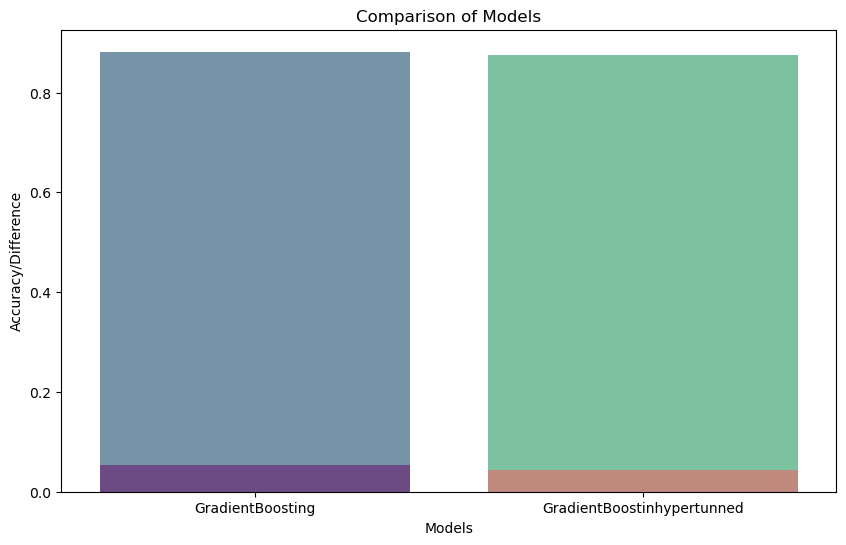

In [303]:
model=['GradientBoosting','GradientBoostinhypertunned']
acc=[0.8818181818181818,0.8757575757575757]
diff=[0.05297218762972178,0.04327521793275224]
plt.figure(figsize=(10,6))

sns.barplot(x=model,y=acc,palette='viridis',alpha=0.7,label='Accuracy')
sns.barplot(x=model,y=diff,palette='magma',alpha=0.7,label='Difference')
plt.xlabel('Models')
plt.ylabel('Accuracy/Difference')
plt.title('Comparison of Models')
plt.show()

# Observation: 
    from the graph, model is best before its hypertunned.

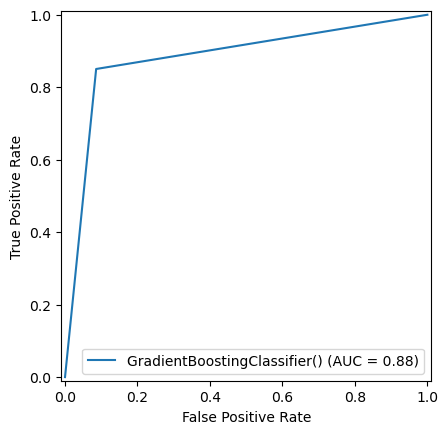

In [304]:
from sklearn import metrics
fpr,tpr,thresholds=metrics.roc_curve(y5_test,pred_gb5)
roc_auc=metrics.auc(fpr,tpr)
display=metrics.RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc,estimator_name=gb5)
display.plot()

In [305]:
import joblib

In [306]:
joblib.dump(gb5,'Titanic_analysis.pkl')

['Titanic_analysis.pkl']

In [307]:
model=joblib.load('Titanic_analysis.pkl')
prediction=model.predict(x5_test)

In [308]:
a=np.array(y5_test)
df=pd.DataFrame()
df['Original']=a
df['Predicted']=prediction
print(df)

     Original  Predicted
0           1          1
1           0          0
2           0          0
3           1          1
4           1          1
..        ...        ...
325         1          1
326         0          0
327         0          0
328         1          1
329         0          1

[330 rows x 2 columns]
